# <span style="color:blue">**Empiler pour comprendre**</span>

### <span style="color:blue">Du neurone simple au multilayer perceptron</span>

*Notebook d’accompagnement du **Blog Post 3** de la série **AI From Scratch / IA pas à pas***.

# <span style="color:blue">**Welcome & Objectives**</span>

Dans les notebooks précédents, on a appris à construire un **neurone artificiel** :

- partie linéaire ;
- biais ;
- activation ;
- loss ;
- gradient descent.

Mais un neurone seul reste limité.

Dans ce notebook, on va accélérer et passer à l’étape suivante :

- partir d’un neurone ;
- construire une **couche de neurones** ;
- puis passer à un **réseau multicouche** ;
- comprendre ce que cela change dans le forward et le backward ;
- voir pourquoi cela permet de résoudre des problèmes plus complexes.

Ici, il y aura **plus de code que de texte**.  
L’objectif n’est pas de redire tout le cours, mais de construire progressivement la logique du **MLP**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## <span style="color:#c8b6ff">**Rappel : un neurone simple**</span>

Jusqu’ici, on manipulait un neurone de ce type :

$$
z = w^\top x + b
\qquad
a = g(z)
$$

Autrement dit :

- on prend plusieurs entrées ;
- on les combine avec des poids ;
- on ajoute un biais ;
- on applique une activation.

Cela fonctionne bien sur des problèmes simples.

Mais un neurone seul ne peut apprendre qu’une **frontière de décision simple**.  
Dès que les relations entre les variables deviennent plus complexes, il atteint vite ses limites.

La suite logique est donc naturelle :

> au lieu d’utiliser un seul neurone, on va en utiliser **plusieurs en parallèle**.

Une première étape consiste à ne plus produire une seule sortie linéaire, mais **plusieurs sorties intermédiaires**.

C’est exactement ce qu’on obtient avec une **couche de neurones**.

100%|██████████| 5000/5000 [00:03<00:00, 1649.09it/s]


<Figure size 1000x400 with 0 Axes>

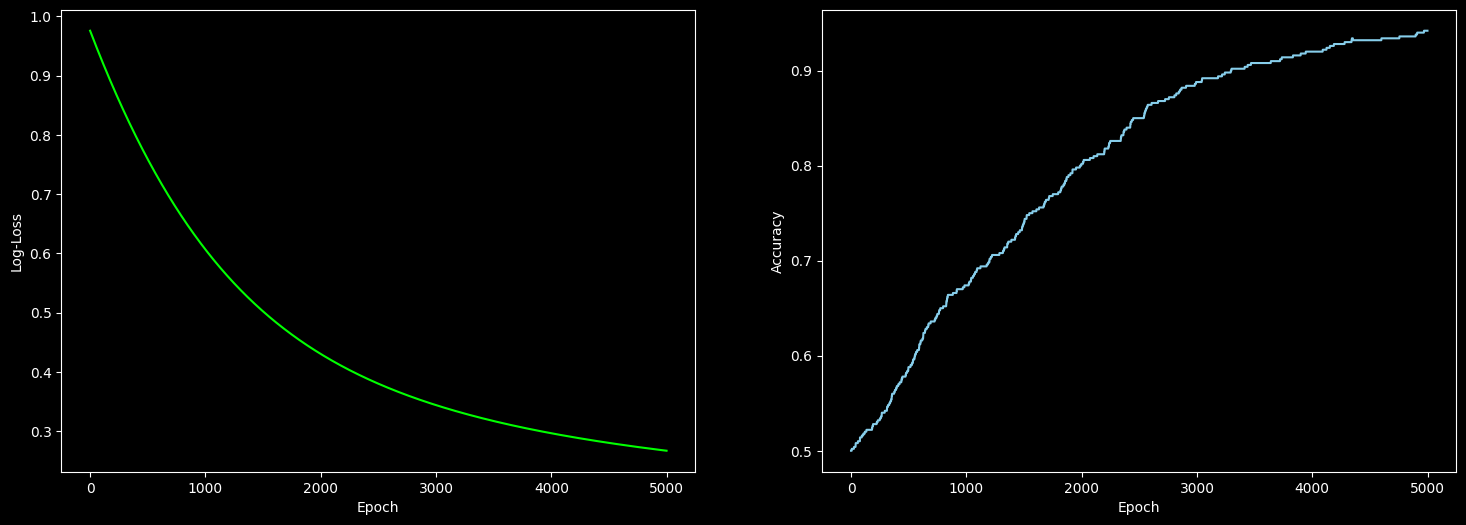

In [2]:
import sys, os #noqa
proj_root = os.path.abspath(os.path.join(os.getcwd(), ".."))  # ajuster le chemin si nécessaire
if proj_root not in sys.path:
    sys.path.insert(0, proj_root) 

from modules.bases import artificial_neuron, forward    # noqa
from modules.utils import create_class_dataset          # noqa

X, y, _, _ = create_class_dataset(n=1000, test_size=0.5, class_sep=10)

w, b, _, _ = artificial_neuron(X, y, epochs=5000)

## <span style="color:#c8b6ff">**Une couche de neurones**</span>

Un neurone seul transforme les entrées en une seule sortie.

Une **couche de neurones**, elle, applique plusieurs neurones en parallèle au même vecteur d’entrée. Chaque neurone apprend donc sa propre combinaison des variables. Au lieu de produire une seule valeur, la couche produit maintenant un **vecteur de sorties**.

### Forme générale

Si l’entrée est un vecteur `x`, alors une couche calcule :

$$
z = xW + b
$$

puis :

$$
a = g(z)
$$

Ici :

- `W` n’est plus un simple vecteur, mais une **matrice de poids** ;
- `b` devient un **vecteur de biais** ;
- la sortie `a` contient plusieurs activations, une par neurone.

Autrement dit :

> une couche = plusieurs neurones appliqués en même temps.

---

### Forme matricielle

Si l’on travaille sur tout un batch de données, on note :

- $X \in \mathbb{R}^{n \times p}$ : matrice d’entrée  
  - `n` = nombre d’observations
  - `p` = nombre de variables d’entrée

- $W \in \mathbb{R}^{p \times h}$ : matrice de poids  
  - `h` = nombre de neurones dans la couche

- $b \in \mathbb{R}^{1 \times h}$ : vecteur de biais

Alors la couche calcule :

$$
Z = XW + b
$$

puis :

$$
A = g(Z)
$$

où :

- $Z \in \mathbb{R}^{n \times h}$ est la matrice des scores linéaires ;
- $A \in \mathbb{R}^{n \times h}$ est la matrice des activations.

### Forme développée

Si l’on travaille avec `n` observations et `p` variables d’entrée, et que la couche contient `h` neurones, on peut écrire :

$$
X =
\begin{bmatrix}
x_{11} & x_{12} & x_{13} & \dots & x_{1p} \\
x_{21} & x_{22} & x_{23} & \dots & x_{2p} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
x_{n1} & x_{n2} & x_{n3} & \dots & x_{np}
\end{bmatrix}
\in \mathbb{R}^{n \times p}
$$

$$
W =
\begin{bmatrix}
w_{11} & w_{12} & \dots & w_{1h} \\
w_{21} & w_{22} & \dots & w_{2h} \\
\vdots & \vdots & \ddots & \vdots \\
w_{p1} & w_{p2} & \dots & w_{ph}
\end{bmatrix}
\in \mathbb{R}^{p \times h}
$$

$$
b =
\begin{bmatrix}
b_1 & b_2 & \dots & b_h
\end{bmatrix}
\in \mathbb{R}^{1 \times h}
$$

Alors :

$$
Z = XW + b
$$

donne :

$$
Z =
\begin{bmatrix}
z_{11} & z_{12} & \dots & z_{1h} \\
z_{21} & z_{22} & \dots & z_{2h} \\
\vdots & \vdots & \ddots & \vdots \\
z_{n1} & z_{n2} & \dots & z_{nh}
\end{bmatrix}
\in \mathbb{R}^{n \times h}
$$

puis :

$$
A = g(Z)
\in \mathbb{R}^{n \times h}
$$

### Comment lire cette écriture

- chaque **ligne de** $X$ correspond à une observation ;
- chaque **colonne de** $X$ correspond à une variable d’entrée ;
- chaque **colonne de** $W$ correspond à un neurone de la couche ;
- chaque **ligne de** $Z$ et de $A$ contient les sorties de toute la couche pour une observation donnée.

Autrement dit :

- on entre avec `p` variables ;
- on passe par `h` neurones ;
- on obtient `h` nouvelles sorties par observation.

### Lecture des dimensions

Cette écriture permet de voir tout de suite la logique :

$$
(n, p)\cdot(p, h) + (1, h) \rightarrow (n, h)
$$

Donc :

- on part de `n` observations avec `p` variables ;
- la couche contient `h` neurones ;
- la sortie contient `h` nouvelles représentations pour chaque observation.

Autrement dit, la couche transforme un espace d’entrée de dimension `p` en un espace de sortie de dimension `h`.


### Ce que fait chaque neurone

Chaque colonne de $W$ correspond à un neurone de la couche.

Donc :

- le neurone 1 apprend sa propre combinaison des `p` variables ;
- le neurone 2 apprend une autre combinaison ;
- etc.

La couche ne produit donc pas une seule lecture du signal d’entrée, mais **plusieurs lectures en parallèle**.


### Et si l’on empile plusieurs couches ?

Si l’on note une couche par un indice $l$, on obtient la forme générale :

$$
Z^{[l]} = A^{[l-1]} W^{[l]} + b^{[l]}
$$

$$
A^{[l]} = g^{[l]}(Z^{[l]})
$$

avec :

- $A^{[0]} = X$
- $W^{[l]} \in \mathbb{R}^{m_{l-1} \times m_l}$
- $b^{[l]} \in \mathbb{R}^{1 \times m_l}$

où :

- $m_{l-1}$ = dimension de la couche précédente
- $m_l$ = nombre de neurones dans la couche `l`

C’est cette écriture qui permet ensuite de décrire un **réseau multicouche** complet.

---

### Gradients : forme générale

Pendant l’apprentissage, chaque couche doit ajuster :

- sa matrice de poids $W^{[l]}$
- son vecteur de biais $b^{[l]}$

La rétropropagation calcule alors les gradients généraux :

$$
\frac{\partial L}{\partial W^{[l]}}
\qquad\text{et}\qquad
\frac{\partial L}{\partial b^{[l]}}
$$

Pour une couche donnée, la forme générale est :

$$
\frac{\partial L}{\partial W^{[l]}}
= \frac{1}{n}\left(A^{[l-1]}\right)^T dZ^{[l]}
$$

$$
\frac{\partial L}{\partial b^{[l]}}
= \frac{1}{n}\sum dZ^{[l]}
$$

où :

- $dZ^{[l]}$ représente l’erreur locale propagée à la couche `l`
- cette erreur dépend :
  - de la couche suivante
  - de la fonction d’activation
  - de la règle de chaîne

### Idée à retenir

Même si le réseau devient plus profond, la logique reste la même :

1. calculer une sortie de couche ;
2. mesurer l’erreur finale ;
3. propager cette erreur vers l’arrière ;
4. corriger les poids et les biais de chaque couche.

Autrement dit :

> une couche ajoute de la capacité d’expression,  
> mais elle s’entraîne toujours avec la même logique générale : **forward, loss, backward, update**.

### Ce que cela change

Avec une couche, on ne produit plus une seule représentation du signal d’entrée. On en produit plusieurs.

Chaque neurone de la couche peut donc apprendre un aspect différent du problème. C’est cette idée qui prépare le passage vers les **couches cachées** puis vers le **multilayer perceptron**.

## <span style="color:#c8b6ff">**Une couche cachée (one hidden layer)**</span>

Une couche seule permet déjà de produire plusieurs représentations d’une même entrée. Mais ce n’est pas encore un vrai **réseau multicouche**.

Pour obtenir cela, on ajoute une nouvelle étape :

1. une **couche cachée** qui transforme l’entrée ;
2. une **couche de sortie** qui transforme cette représentation intermédiaire en prédiction finale.

On obtient alors la structure suivante :

$$
X \rightarrow Z^{[1]} \rightarrow A^{[1]} \rightarrow Z^{[2]} \rightarrow A^{[2]}
$$

où :

- $Z^{[1]} = XW^{[1]} + b^{[1]}$
- $A^{[1]} = g^{[1]}(Z^{[1]})$
- $Z^{[2]} = A^{[1]}W^{[2]} + b^{[2]}$
- $A^{[2]} = g^{[2]}(Z^{[2]})$

Autrement dit :

- la première couche apprend une **représentation intermédiaire** ;
- la deuxième couche utilise cette représentation pour produire la sortie.

### Idée à retenir

Une couche cachée ne donne pas encore un réseau “profond”, mais elle introduit déjà l’idée essentielle des réseaux de neurones :
> apprendre une représentation intermédiaire avant de produire la sortie finale.

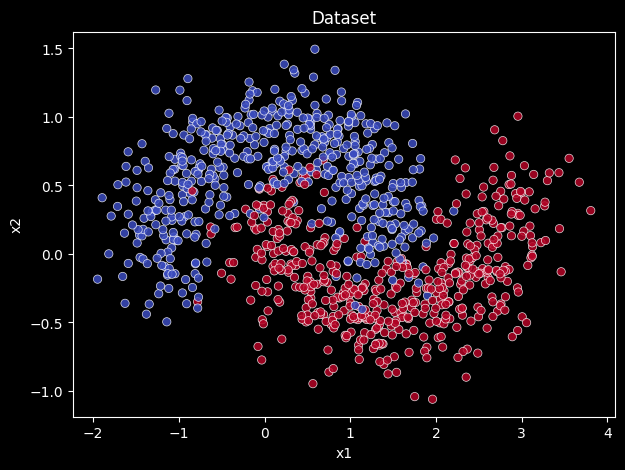

In [19]:
from modules.utils import create_moons_dataset, plot_decision_boundary

X, y = create_moons_dataset(n_samples=1000, noise=0.25, rotate_deg=2, as_dataframe=False)

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

plt.figure(figsize=(7, 5))
plt.scatter(
    X[:, 0], X[:, 1],
    c=y,
    cmap="coolwarm",
    edgecolors="white",
    linewidths=0.5,
    alpha=0.85
)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Dataset")
plt.show()

100%|██████████| 10000/10000 [00:04<00:00, 2474.95it/s]


<Figure size 1000x400 with 0 Axes>

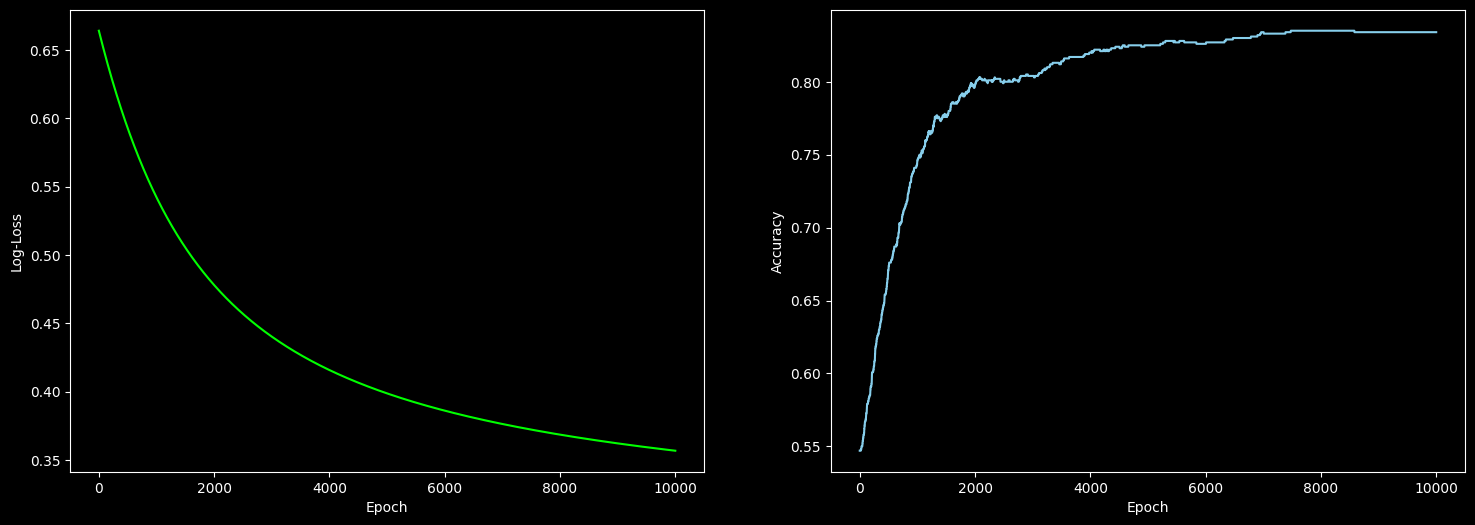

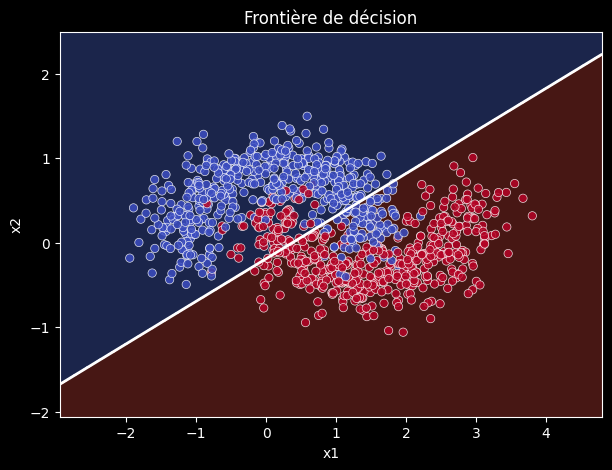

In [4]:
# Perf de nottre neurone sur cette tache
w, b, _, _= artificial_neuron(X, y, epochs=10000)
plot_decision_boundary(X, y, w, b, forward)

### Lecture rapide

Le neurone apprend bien quelque chose : la loss diminue.  
Mais sa performance reste faible, et la frontière de décision reste trop simple pour suivre la structure en spirales.

Autrement dit, le problème n’est pas seulement l’optimisation.  
Le problème est surtout que **un seul neurone n’a pas assez de capacité** pour modéliser une séparation aussi complexe.

C’est exactement pour cela qu’on va maintenant passer à une **couche de plusieurs neurones**.

## Avec une couche

In [5]:
def initialize(X, h):
    """
    p = nb of features et h = nb of neurones
    """
    p = X.shape[1]
    
    W1 = np.random.randn(p, h) # cette couche est composée de h neurones qui possede chacun p poids
    b1 = np.random.randn(h)    # ici on a pour chaque neuron un biais => donc h biais
    
    W2 = np.random.randn(h, 1)    # on return 1 output donc on pondere les sortie de chacun des h neurone de la couche precedente
    b2 = np.random.randn(1)     # plus le biais (scalaire pour fournir un output)
    
    weights = [W1, W2]
    biases  = [b1, b2]

    return {"W": weights, "b": biases}

In [6]:
params = initialize(X, 8)
for w in params["W"]:
    print(w.shape)
    
for b in params["b"]:
    print(np.shape(b))

(2, 8)
(8, 1)
(8,)
(1,)


In [7]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def forward_pass(X, params, activation=sigmoid):
    weights = params["W"]
    biases  = params["b"]
    
    Act = []
    
    for W, b in zip(weights, biases):
        X = activation(X @ W + b)
        Act.append(X)
    return Act

In [8]:
Act = forward_pass(X, params)
for a in Act:
    print(a.shape)

(1000, 8)
(1000, 1)


In [9]:
from modules.bases import log_loss

loss = log_loss(y, Act[1])
print(loss)

1.1016673948516873


In [10]:
def backward_prop(params, X, y, Act, learning_rate=0.001):
    """
    Backward propagation pour un réseau :
    X -> hidden(sigmoid) -> output(sigmoid)

    params["W"] = [W1, W2]
    params["b"] = [b1, b2]

    X  : shape (n, p)
    y  : shape (n,) ou (n,1)
    A1 : shape (n, h)
    A2 : shape (n, 1)
    """
    n = X.shape[0]
    y = y.reshape(-1, 1)  # pour éviter les problèmes de shape

    A1, A2 = Act[0], Act[1]
    W1, W2 = params["W"]
    b1, b2 = params["b"]

    # -----------------------------
    # Output layer
    # -----------------------------
    dZ2 = A2 - y                          # (n, 1)
    dW2 = (1 / n) * (A1.T @ dZ2)         # (h, 1)
    db2 = (1 / n) * np.sum(dZ2, axis=0)  # (1,)

    # -----------------------------
    # Hidden layer
    # -----------------------------
    dA1 = dZ2 @ W2.T                     # (n, h)
    dZ1 = dA1 * A1 * (1 - A1)            # sigmoid'(Z1) = A1 * (1 - A1)

    dW1 = (1 / n) * (X.T @ dZ1)          # (p, h)
    db1 = (1 / n) * np.sum(dZ1, axis=0)  # (h,)

    # -----------------------------
    # Stocker les gradients
    # -----------------------------
    gradients = {
        "dW1": dW1,
        "db1": db1,
        "dW2": dW2,
        "db2": db2
    }

    # -----------------------------
    # Update parameters
    # -----------------------------
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

    updated_params = {
        "W": [W1, W2],
        "b": [b1, b2]
    }

    return gradients, updated_params

In [11]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score

def olp(X, y, h, learning_rate=0.001, epochs=10000, plot=True):
    """
    One Layer Perceptron
    Réseau à une couche cachée + une couche de sortie
    """
    
    # 1) Initialisation
    np.random.seed(42)
    params = initialize(X, h)
    
    Losses = []
    Acc = []
    
    y_true = y.ravel()
    
    for _ in tqdm(range(epochs)):
        # 2) Forward
        A = forward_pass(X, params, activation=sigmoid)

        # 3) Loss + accuracy
        error = log_loss(y.reshape(-1, 1), A[1])
        Losses.append(error)
        
        pred_label = np.where(A[1] >= 0.5, 1, 0).ravel()
        accuracy = accuracy_score(y_true, pred_label)
        Acc.append(accuracy)

        # 4) Backward + update
        _, params = backward_prop(
            params, X, y, A, learning_rate=learning_rate
        )

    if plot:
        plt.style.use("dark_background")
        fig, ax = plt.subplots(1, 2, figsize=(18, 6))
        
        ax[0].plot(Losses, color='lime')
        ax[0].set_xlabel("Epoch")
        ax[0].set_ylabel("Log-Loss")
        ax[0].set_title("Loss")
        
        ax[1].plot(Acc, color='skyblue')
        ax[1].set_xlabel("Epoch")
        ax[1].set_ylabel("Accuracy")
        ax[1].set_title("Accuracy")
        
        plt.show()
    
    return params, Losses, Acc

100%|██████████| 5000/5000 [00:51<00:00, 96.94it/s] 


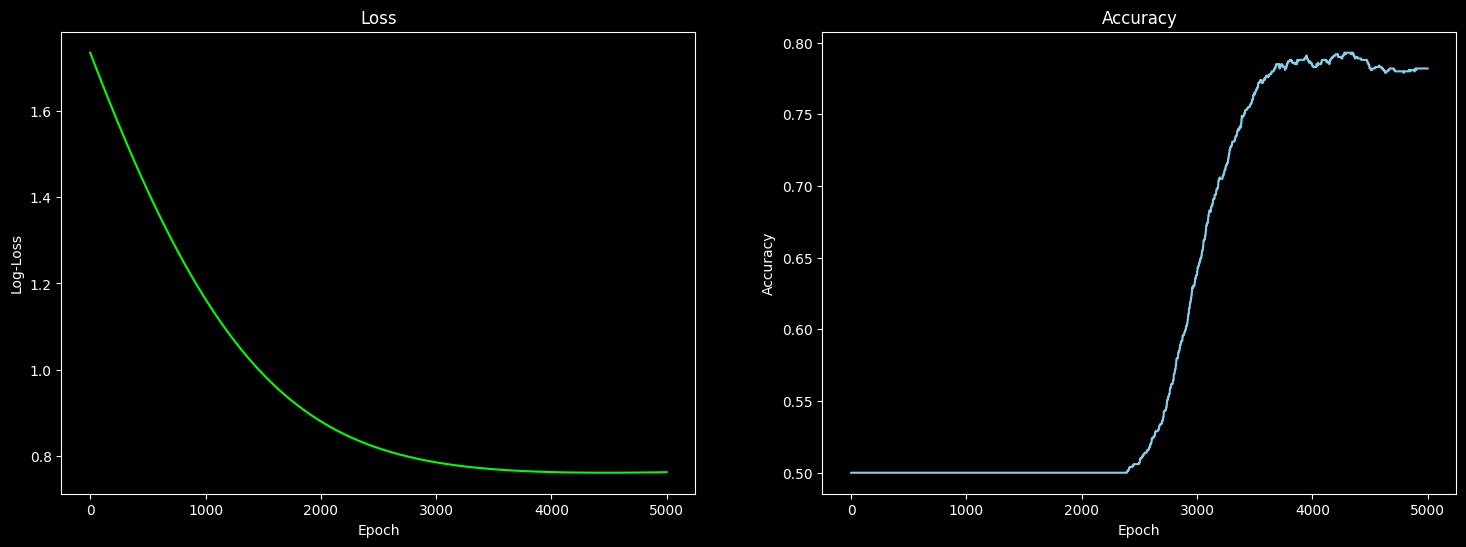

In [12]:
OLP = olp(X, y, h=4, epochs=5000, learning_rate=0.001)

### Interprétation

Ici, le modèle apprend un peu : la log-loss diminue.  
Mais l'accuracy reste proche du hasard, ce qui montre que cette architecture n'arrive pas encore à construire une bonne frontière de décision.

Autrement dit, ajouter des neurones augmente bien la capacité du modèle, mais cela ne garantit pas automatiquement de meilleures performances.

Il faut aussi faire attention à plusieurs points :

- le choix de l'activation ;
- le learning rate ;
- l'initialisation ;
- le prétraitement des données ;
- et plus généralement la capacité réelle de l'architecture à apprendre le problème posé.

> Plus de neurones ne veut pas dire automatiquement meilleur modèle.  
> Cela veut seulement dire plus de capacité potentielle.

In [13]:
def plot_decision_boundary_olp(X, y, params, activation=sigmoid, title="Frontière de décision"):
    """
    Trace la frontière de décision d'un modèle à une couche cachée.

    X : array shape (n, 2)
    y : array shape (n,) ou (n,1)
    params : paramètres appris du réseau
    """

    # Bornes du graphe
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    # Grille de points
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Forward sur la grille
    A_grid = forward_pass(grid, params, activation=activation)
    proba = A_grid[1].reshape(xx.shape)

    # Décision binaire
    Z = (proba >= 0.5).astype(int)

    plt.style.use("dark_background")
    plt.figure(figsize=(8, 8))

    # Fond = zones prédites
    plt.contourf(xx, yy, Z, alpha=0.35, cmap="coolwarm")

    # Ligne de décision p=0.5
    plt.contour(xx, yy, proba, levels=[0.5], colors="white", linewidths=2)

    # Données
    plt.scatter(
        X[:, 0], X[:, 1],
        c=y.ravel(),
        cmap="coolwarm",
        edgecolors="white",
        linewidths=0.5,
        alpha=0.8
    )

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.show()

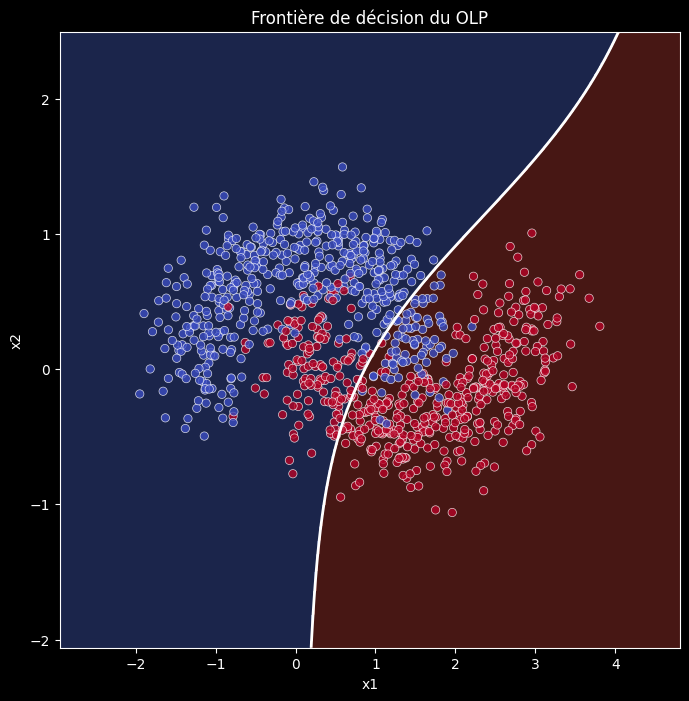

In [14]:
params, Losses, Acc = OLP
plot_decision_boundary_olp(X, y, params, title="Frontière de décision du OLP")

### Interprétation des frontières de décision

Les deux graphes montrent bien la différence entre **capacité du modèle** et **performance réelle**.

Le **neurone seul** apprend une frontière très simple, presque linéaire.  
Il sépare l’espace en deux grandes zones, mais il ne peut pas épouser la structure en spirales du dataset.

Le **OLP** (avec une couche cachée) produit déjà une frontière beaucoup plus riche.  
On voit qu’il essaie de construire plusieurs régions de décision locales : sa capacité est donc bien supérieure à celle d’un neurone isolé.

Mais cette frontière reste encore mal adaptée au problème.  
Elle est plus complexe, sans être encore vraiment alignée avec la géométrie des spirales.

Cela signifie deux choses importantes :

- ajouter une couche augmente bien la **capacité expressive** du modèle ;
- mais cette capacité ne garantit pas automatiquement une bonne solution.

Autrement dit, le OLP a bien plus de potentiel que le neurone simple, mais ici il n’a pas encore trouvé une représentation suffisamment bonne du problème.

Cela peut venir de plusieurs facteurs :

- le modèle n’a pas encore assez bien convergé ;
- le learning rate n’est pas idéal ;
- l’activation n’est peut-être pas la meilleure ;
- ou bien une seule couche cachée reste encore insuffisante pour ce dataset très non linéaire.

> Le passage du neurone simple au OLP montre donc un gain de flexibilité clair, mais aussi une idée essentielle du deep learning : **plus de capacité ne suffit pas, il faut aussi réussir à bien entraîner cette capacité.**

# <span style="color:purple">**MultiLayer Perceptron - MLP**</span>

On vient donc de franchir une première étape importante :

- on est passé du neurone seul à une couche de plusieurs neurones ;
- on a vu que cela augmente bien la capacité du modèle ;
- mais on a aussi vu que cela ne suffit pas toujours à résoudre des problèmes vraiment complexes.

Autrement dit, une seule couche cachée peut déjà enrichir la représentation des données, mais elle reste encore limitée dans les transformations qu’elle peut apprendre.

La suite logique est donc naturelle :

> au lieu de s’arrêter à une seule couche intermédiaire, on va maintenant en empiler plusieurs.

C’est exactement ce qu’on appelle un **multilayer perceptron** :

- plusieurs couches ;
- plusieurs transformations successives ;
- plusieurs niveaux de représentation.

Et c’est cette profondeur qui va permettre au réseau d’apprendre des structures beaucoup plus riches que celles accessibles à un neurone isolé ou à une seule couche.

## Initialization

**Analogie**

Prenons une première couche de **3 neurones** qui reçoit **2 inputs**. Chaque neurone reçoit les 2 entrées, donc chaque neurone possède :

- **2 poids** et  **1 biais**

Comme la couche contient 3 neurones, elle produit donc **3 outputs**. Donc pour cette couche :

- `W1` contient les poids de tous les neurones
- `b1` contient les biais de tous les neurones

Si on code avec la logique :

$$
Z = XW + b
$$

alors :

- `W1` a pour shape **(nb de features, nb de neurones)**
- `b1` a pour shape **(nb de neurones, )**

Donc ici :

- `W1 = (2, 3)`
- `b1 = (3,)`

Cela veut dire :

- 2 lignes car il y a 2 features d’entrée
- 3 colonnes car il y a 3 neurones dans la couche

Chaque **colonne** de `W1` correspond donc aux poids d’un neurone.


### Si on ajoute une nouvelle couche

La couche suivante ne prend plus `X` directement en entrée.

Elle prend les **outputs de la couche précédente**.</br>Donc si la couche 1 produit `3` sorties, alors la couche 2 recevra `3` entrées.

Supposons maintenant que cette couche 2 contienne `2` neurones.

Alors :

- `W2 = (3, 2)`
- `b2 = (2,)`

Pourquoi ?

- `3` car chaque neurone de la couche 2 reçoit les `3` sorties de la couche précédente
- `2` car la couche contient `2` neurones



## Généralisation

Pour une couche `h` :

- $n_{h-1}$ = nombre de sorties de la couche précédente
- $n_h$ = nombre de neurones dans la couche actuelle

Alors :

- **Weights** : `W[h]` a pour shape **($n_{h-1}$, $n_h$)**
- **Biases** : `b[h]` a pour shape **($n_h$, )**

avec `h0 = X` et `n0 = p` (nombre de features d’entrée)



### Inputs de la fonction

La fonction d’initialisation doit donc prendre :

- `input_dim` → le nombre de variables d'input `p`
- `[n1, n2, n3, ..., nH]` → une liste contenant le nombre de neurones dans chaque couche
- `output_dim` la dimention de l'output qu'on souhaite retourner

Exemple :

- `input_dum = 2`
- `layers = [3, 2]`
- `output_dim = 1`

Cela veut dire :

- couche 1 : 3 neurones
- couche 2 : 2 neurones

et produit une sortie


### Logique

1. on récupère le nombre total de couches intermédiaire à céer (H couches)
2. on bouche sur $[n_1, n_2, ..., n_H]$
3. pour chaque couche, on crée :
   - $W[h]$ de shape $(input\_dim, n_h)$
   - $b[h]$ de shape $(n_h,)$
4. on stocke tout ça dans un dictionnaire
5. on met à jours input_dim avec $n_h$ pour la prochaine couche

In [20]:
# Pour commencer on va prétraiter X
from sklearn.preprocessing import StandardScaler
# np.isnan(X).sum() # no nan
# np.min(X), np.max(X) # (-13.124740424945832, 13.327160365619482)

scaler = StandardScaler()

X = scaler.fit_transform(X)
np.min(X), np.max(X) # (-2.496213349287914, 2.5460517330989503)

(-2.496213349287914, 2.5460517330989503)

In [16]:
def initialization(input_dim, hidden_layers = [32, 32, 32], output_dim=1):
    H = len(hidden_layers)
    
    params = {}
    for h in range(0, H):
        params["W" + str(h+1)] = np.random.randn(input_dim, hidden_layers[h])
        params["b" + str(h+1)] = np.random.randn(hidden_layers[h])
        input_dim = hidden_layers[h]
    
    params["W" + str(H+1)] = np.random.randn(hidden_layers[-1], output_dim)
    params["b" + str(H+1)] = np.random.randn(output_dim)
        
    return params

params = initialization(input_dim=X.shape[1])
params.keys() # 3 couches cachés + couche de sortie  

dict_keys(['W1', 'b1', 'W2', 'b2', 'W3', 'b3', 'W4', 'b4'])

## Forward Propagation

Ici, on fait passer les données dans le réseau.

Les paramètres ont déjà été initialisés. Le rôle du forward est donc simplement de :

1. calculer la combinaison linéaire de chaque couche ;
2. appliquer une fonction d’activation ;
3. transmettre la sortie à la couche suivante.

Pour une couche `h`, on écrit :

$$
Z^{[h]} = A^{[h-1]}W^{[h]} + b^{[h]}
$$

$$
A^{[h]} = g^{[h]}(Z^{[h]})
$$

avec :

$$
A^{[0]} = X
$$

Autrement dit :

- la couche précédente fournit une activation ;
- cette activation est multipliée par les poids de la couche courante ;
- on ajoute le biais ;
- puis on applique une fonction d’activation.

### Inputs de la fonction

La fonction de forward propagation doit donc prendre :

- les `params`
- les features `X`
- éventuellement une liste d’activations, une par couche

### Fonctions d’activation

Ici, on veut laisser la possibilité de choisir, pour chaque couche, parmi plusieurs fonctions :

- `ReLU`
- `sigmoid`
- `tanh`

Mais attention :

> toutes les activations ne conviennent pas à tous les problèmes.

Le choix dépend du type de tâche :

- `ReLU`, `tanh` : souvent utilisée dans les couches cachées
- `sigmoid` : utile pour une sortie binaire

In [17]:
def ReLU(x):
    return np.maximum(0, x)

def tanh(x):
    return np.tanh(x)

def set_activation(prefix):
    if prefix=="rel":
        activation=ReLU
    elif prefix=="sig":
        activation=sigmoid
    elif prefix=="tan":
        activation=tanh
    else:
        raise ValueError(f"activation {prefix} inconnue. Selectionner 'rel' for ReLU, 'sig' for Sigmoid, 'tan', for Tanh")
    return activation

# Se référer aux dérivées de ces fonctions
def dReLU(x):
    return np.where(x > 0, 1, 0)

def dsigmoid(x):
    return sigmoid(x) * (1 - sigmoid(x))

def dtanh(x):
    return 1.0 - np.tanh(x)**2

def set_derivative(prefix):
    if prefix=="rel":
        derivative=dReLU
    elif prefix=="sig":
        derivative=dsigmoid
    elif prefix=="tan":
        derivative=dtanh
    else:
        raise ValueError(f"activation {prefix} inconnue. Selectionner 'rel' for ReLU, 'sig' for Sigmoid, 'tan' for Tanh")
    return derivative

def get_function_and_derivatives(n_layers, prefixes):

    if isinstance(prefixes, (list, tuple)):
        if len(prefixes) != n_layers:
            raise ValueError(
                f"{len(prefixes)} activations passées. le réseau requiert {n_layers} activations"
            )
    elif isinstance(prefixes, str):
        prefixes=[prefixes] * n_layers
    else:
        raise ValueError("Only list, tuple et str acceptés")
    
    activation_functions = []
    
    for pref in prefixes:
        a = set_activation(pref)
        activation_functions.append(a)
    
    derivatives = []
    for pref in prefixes:
        g = set_derivative(pref)
        derivatives.append(g)
    return activation_functions, derivatives

activation_functions, derivatives = get_function_and_derivatives(4, ['rel', 'rel', 'rel', 'sig'])

In [18]:
def forward_propagation(X, params, activation_functions):
    
    # Ici on vérifie les fonctions d'activation passées
    H = len(params) // 2
    
    # Mtn on a les activations on peux passer à la forward pass
    activations = {"A0": X}
    aggregates = {}
    
    for h, f in zip(range(1, H+1), activation_functions): # h = previous layer et f = activation function de la current layer
        # on fait d'abord Z = XW + b
        Z = activations["A" + str(h-1)] @ params["W" + str(h)] + params["b" + str(h)]
        # on active: A = f(Z)
        activations["A" + str(h)] = f(Z)
        aggregates["Z" + str(h)] = Z
    
    return aggregates, activations

Zh, Ah = forward_propagation(X, params, activation_functions)
print(f"Zh shape : {Zh.keys()}")
print(f"Ah shape : {Ah.keys()}")
print("Taille de la dernière activation :", Ah["A" + str(len(Ah) - 1)].shape)


Zh shape : dict_keys(['Z1', 'Z2', 'Z3', 'Z4'])
Ah shape : dict_keys(['A0', 'A1', 'A2', 'A3', 'A4'])
Taille de la dernière activation : (1000, 1)


## Backward Propagation

Pour un réseau avec **une couche cachée**, on avait :

### Couche de sortie

$$
dZ^{[2]} = A^{[2]} - y
$$

Puis :

$$
dW^{[2]} = \frac{1}{n} \left(A^{[1]}\right)^T dZ^{[2]}
$$

$$
db^{[2]} = \frac{1}{n} \sum dZ^{[2]}
$$

### Couche cachée

On commence par propager l’erreur vers l’arrière :

$$
dA^{[1]} = dZ^{[2]} \left(W^{[2]}\right)^T
$$

Puis on tient compte de l’activation :

$$
dZ^{[1]} = dA^{[1]} \odot g'^{[1]}(Z^{[1]})
$$

Si l’activation de la couche cachée est une sigmoïde, alors :

$$
dZ^{[1]} = dA^{[1]} \odot A^{[1]}(1 - A^{[1]})
$$

Ensuite :

$$
dW^{[1]} = \frac{1}{n} X^T dZ^{[1]}
$$

$$
db^{[1]} = \frac{1}{n} \sum dZ^{[1]}
$$



### Si on ajoute une deuxième couche cachée

On obtient par exemple :

### Couche de sortie

$$
dZ^{[3]} = A^{[3]} - y
$$

$$
dW^{[3]} = \frac{1}{n} \left(A^{[2]}\right)^T dZ^{[3]}
$$

$$
db^{[3]} = \frac{1}{n} \sum dZ^{[3]}
$$

### Couche cachée 2

$$
dA^{[2]} = dZ^{[3]} \left(W^{[3]}\right)^T
$$

$$
dZ^{[2]} = dA^{[2]} \odot g'^{[2]}(Z^{[2]})
$$

$$
dW^{[2]} = \frac{1}{n} \left(A^{[1]}\right)^T dZ^{[2]}
$$

$$
db^{[2]} = \frac{1}{n} \sum dZ^{[2]}
$$

### Couche cachée 1

$$
dA^{[1]} = dZ^{[2]} \left(W^{[2]}\right)^T
$$

$$
dZ^{[1]} = dA^{[1]} \odot g'^{[1]}(Z^{[1]})
$$

$$
dW^{[1]} = \frac{1}{n} X^T dZ^{[1]}
$$

$$
db^{[1]} = \frac{1}{n} \sum dZ^{[1]}
$$



## Généralisation

Pour une couche quelconque `h`, on procède toujours de la même façon :

1. on récupère l’erreur qui vient de la couche suivante ;
2. on la filtre avec la dérivée de l’activation ;
3. on en déduit les gradients des poids et des biais.

La forme générale est donc :

$$
dA^{[h-1]} = dZ^{[h]} \left(W^{[h]}\right)^T
$$

$$
dZ^{[h-1]} = dA^{[h-1]} \odot g'^{[h-1]}(Z^{[h-1]})
$$

$$
dW^{[h]} = \frac{1}{n} \left(A^{[h-1]}\right)^T dZ^{[h]}
$$

$$
db^{[h]} = \frac{1}{n} \sum dZ^{[h]}
$$



## Point important

Ce qui change d’une couche à l’autre, ce n’est pas la logique du backward.  
Ce qui change surtout, c’est :

- la **source de l’erreur propagée**
- la **fonction d’activation utilisée**
- donc la forme de **\( g'(Z) \)**

Autrement dit :

> le backward reste toujours une propagation d’erreur couche par couche,  
> mais chaque couche doit utiliser la bonne dérivée d’activation.

In [19]:
def backward_propagation(y, params, activations, aggregates, derivatives, learning_rate=0.001):
    H = len(params) // 2
    
    # le dernier dZ est : AH - y
    n = len(y)
    y = y.reshape(-1, 1)
    # assert activations["A" + str(H)].shape == y.shape # s'assurer que les tailles macthent
    dZH = activations["A" + str(H)] - y
    gradients = {}
        
    for h in range(H, 0, -1):
        # En ce referant aux formules en amont
        # dAh-1 = dZh @ Wh.T
        # dZh-1 = dAh-1 @ g'(Zh-1) where g' = derivative of activation
        # dWh = 1 / n * Ah-1.T @ dZh
        # dbh = 1 / n * sum(dZh)
        gradients["dW" + str(h)] = (1 / n) * activations["A" + str(h-1)].T @ dZH
        gradients["db" + str(h)] = (1 / n) * np.sum(dZH, axis=0)
        
        if h > 1:
            prev_dA = dZH @ params["W" + str(h)].T
            g = derivatives[h-2]
            dZH = prev_dA * g(aggregates["Z" + str(h-1)])
    
    for h in range(1, H+1):
        params["W" + str(h)] = params["W" + str(h)] - learning_rate  * gradients["dW" + str(h)]
        params["b" + str(h)] = params["b" + str(h)] - learning_rate  * gradients["db" + str(h)]
    
    return gradients, params

gradients, params = backward_propagation(y, params, Ah, Zh, derivatives)
print(f"Gradients : {gradients.keys()}")
print(f"Params : {params.keys()}")

Gradients : dict_keys(['dW4', 'db4', 'dW3', 'db3', 'dW2', 'db2', 'dW1', 'db1'])
Params : dict_keys(['W1', 'b1', 'W2', 'b2', 'W3', 'b3', 'W4', 'b4'])


## <span style="color:#c8b6ff">**Full Artificial neural network**</span>

On a maintenant toutes les briques nécessaires pour construire un **réseau complet**.

A chaque epoch, le réseau doit :

1. faire passer les données dans toutes les couches ;
2. produire une prédiction finale ;
3. calculer la loss ;
4. propager l’erreur vers l’arrière ;
5. mettre à jour tous les poids et biais.

La logique générale ne change donc pas.  
Ce qui change, c’est seulement l’échelle :

> On n’entraîne plus un neurone ou une seule couche, mais toute une chaîne de transformations successives.

C’est précisément cette chaîne qui constitue un **neural network**.

In [20]:
def ANN(X, y, hidden_layers=[32, 32, 32], output_dim=1, activations="sig", learning_rate=0.001, epochs=1000, plot=True):
    np.random.seed(42)
    
    # 1) Inititalisation
    params = initialization(input_dim=X.shape[1], hidden_layers=hidden_layers, output_dim=output_dim)
    
    # Boucle d'entrainement
    Losses = []
    Accuracy = []
    Gradients = []
    
    for ep in tqdm(range(epochs)):
        # 2) Forward
        H = len(params) // 2
        activation_functions, derivatives = get_function_and_derivatives(H, activations)
        Zh, Ah = forward_propagation(X, params, activation_functions)

        # 3) Loss à calculer tous les 10 epochs
        if ep % 10 == 0:
            y_vec = y.reshape(-1, 1)
            A = Ah["A" + str(H)]
            error = log_loss(y_vec, A)
            pred_label = (A >= 0.5).astype(int).ravel()  # rendre binaire avant accuracy()
            score = accuracy_score(y.ravel(), pred_label)
            Losses.append(error)
            Accuracy.append(score)
        
        # 4) Backward
        grads, params = backward_propagation(y, params, Ah, Zh, derivatives, learning_rate=learning_rate)
        Gradients.append(grads)
    
    if plot:
        plt.style.use("dark_background")
        _, ax = plt.subplots(1, 2, figsize=(18, 6))
        
        ax[0].plot(Losses, color='lime')
        ax[0].set_xlabel("Epoch")
        ax[0].set_ylabel("Log-Loss")
        ax[0].set_title("Loss")
        
        ax[1].plot(Accuracy, color='skyblue')
        ax[1].set_xlabel("Epoch")
        ax[1].set_ylabel("Accuracy")
        ax[1].set_title("Accuracy")
        
        plt.show()
    
    return params, Losses, Accuracy, Gradients

In [21]:
def plot_decision_boundary_ann(X, y, params, activations="sig", resolution=400, title="Decision boundary"):
    """
    Trace la frontière de décision d'un réseau ANN entraîné.

    Paramètres
    ----------
    X : np.ndarray
        Données d'entrée de shape (n_samples, 2). Fonction prévue pour 2 features.
    y : np.ndarray
        Labels binaires de shape (n_samples,) ou (n_samples, 1).
    params : dict
        Paramètres du réseau (W1, b1, ..., WH, bH).
    activations : str | list | tuple
        Activation(s) à utiliser dans le réseau.
    resolution : int
        Densité de la grille.
    title : str
        Titre du graphique.
    """
    if X.shape[1] != 2:
        raise ValueError("Cette fonction ne marche que pour X avec exactement 2 features.")

    # 1) Préparer les activations du réseau
    H = len(params) // 2
    activation_functions, _ = get_function_and_derivatives(H, activations)

    # 2) Créer une grille 2D
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, resolution),
        np.linspace(y_min, y_max, resolution)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    # 3) Faire le forward sur la grille
    Zh_grid, Ah_grid = forward_propagation(grid, params, activation_functions)

    A_final = Ah_grid["A" + str(H)]   # sortie finale
    proba = A_final.reshape(xx.shape)

    # 4) Transformer en classes
    pred = (proba >= 0.5).astype(int)

    # 5) Plot
    plt.style.use("dark_background")
    plt.figure(figsize=(8, 8))

    # Zones de décision
    plt.contourf(xx, yy, pred, alpha=0.35, cmap="coolwarm")

    # Ligne frontière p = 0.5
    plt.contour(xx, yy, proba, levels=[0.5], colors="white", linewidths=2)

    # Points du dataset
    plt.scatter(
        X[:, 0], X[:, 1],
        c=y.ravel(),
        cmap="coolwarm",
        edgecolors="white",
        linewidths=0.5,
        alpha=0.85
    )

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.show()

100%|██████████| 30000/30000 [02:33<00:00, 195.46it/s]


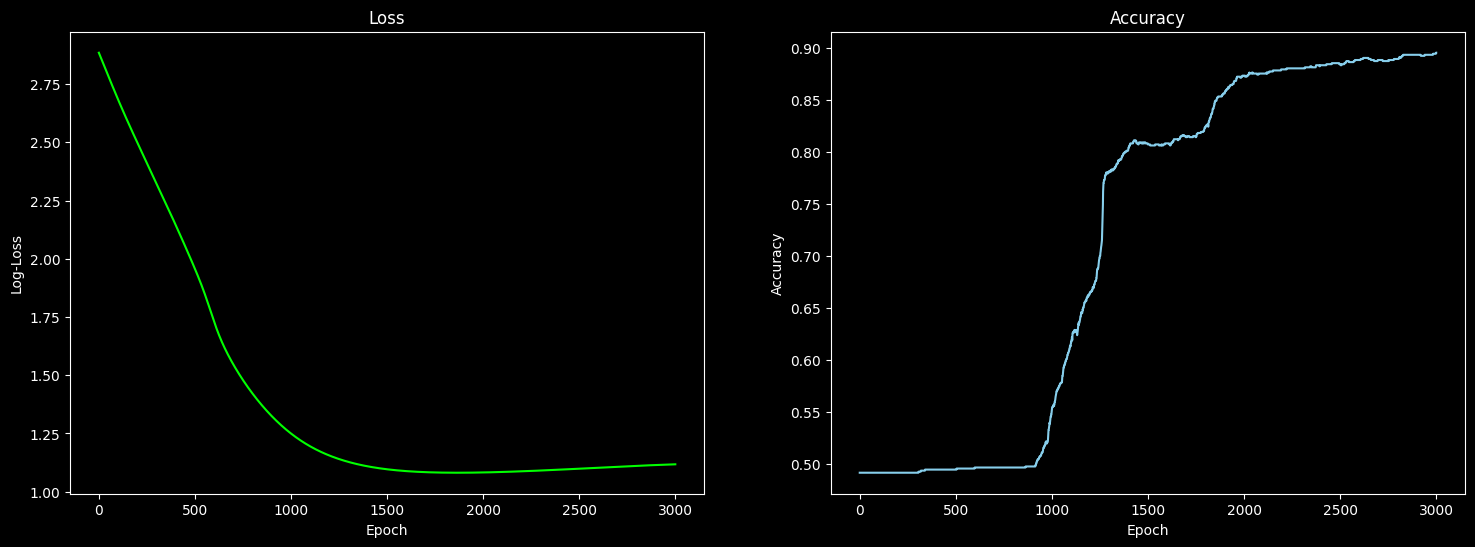

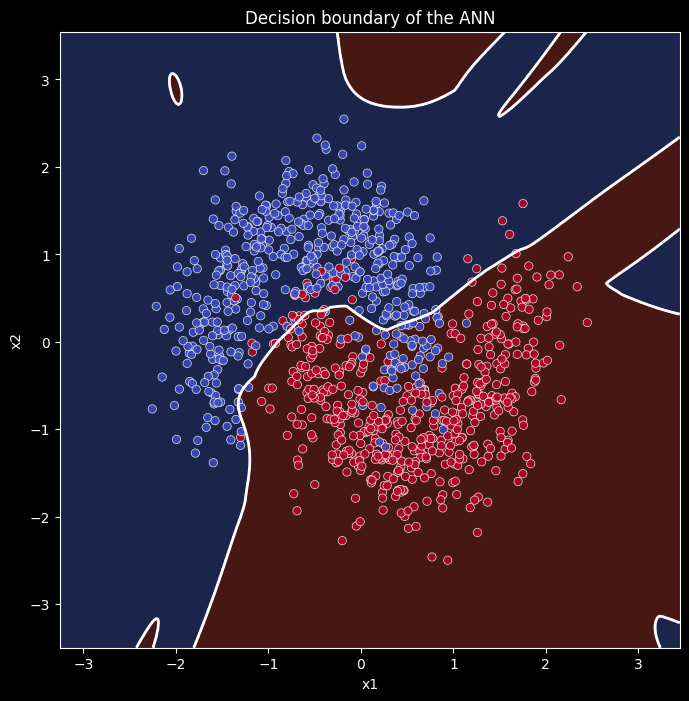

In [22]:
params, Losses, Accuracy, Gradients = ANN(
    X, y, hidden_layers=[32, 16, 16], activations=['tan', 'rel', 'tan', 'sig'], 
    epochs=30000, learning_rate=0.000075
)

plot_decision_boundary_ann(
    X, y,
    params=params,
    activations=['tan', 'rel', 'tan', 'sig'],
    title="Decision boundary of the ANN"
)

### Interprétation des résultats du MLP

Le MLP obtient ici de bien meilleurs résultats que le one-layer perceptron.

La **log-loss diminue fortement** au cours de l’entraînement, ce qui montre que le modèle apprend correctement.  
L’**accuracy**, elle, passe d’un niveau proche du hasard à presque `0.90`, ce qui traduit une vraie amélioration de la qualité de classification.

La frontière de décision confirme ce gain :

- elle est plus souple ;
- plus locale ;
- et surtout mieux adaptée à la structure réelle des données.

À l’inverse, le **one-layer** restait capable de produire une séparation non linéaire, mais encore trop simple et trop rigide pour bien modéliser tout le dataset.

La différence essentielle est donc la suivante :

- le one-layer essaie surtout de séparer directement les données ;
- le MLP, lui, apprend d’abord plusieurs transformations intermédiaires avant de produire la décision finale.

C’est exactement ce que permet la profondeur du réseau :

> empiler plusieurs couches ne sert pas seulement à ajouter des paramètres,  
> mais à apprendre des représentations plus riches du problème.

Autrement dit, le MLP montre ici pourquoi un réseau multicouche peut dépasser clairement une architecture plus simple.

# <span style="color:#c8b6ff">**Vers PyTorch**</span>

Jusqu’ici, on a volontairement tout construit **from scratch**.

On a commencé par la régression linéaire, puis on a introduit le perceptron, les fonctions d’activation, le neurone artificiel, les couches, puis enfin les réseaux multicouches.

Ce détour était important : avant d’utiliser une librairie, il fallait comprendre ce qu’elle automatise.

Maintenant, on peut changer d’échelle.

L’objectif de cette dernière partie n’est plus de redémontrer chaque formule à la main, mais de voir comment toutes ces briques se traduisent dans **PyTorch**, la librairie la plus utilisée aujourd’hui pour construire et entraîner des réseaux de neurones.

Autrement dit :

- ce qu’on a appris jusqu’ici reste exactement le même ;
- mais PyTorch nous permet de l’écrire plus proprement ;

Dans cette partie, on va donc relire les concepts vus depuis le début, mais cette fois avec les objets et la logique de PyTorch.

[Pytorch Init](https://github.com/aurvl/AI-Step-by-Step/blob/main/bp3-neural-networks/vers_pytorch.ipynb)

# <span style="color:#c8b6ff">**Conclusion**</span>

Dans ce notebook, on a franchi une étape importante.

On est parti du **neurone seul**, puis on a vu qu’une seule transformation, même activée, reste vite limitée dès que les relations entre les variables deviennent plus complexes.  
C’est ce qui nous a conduits vers :

- la **couche de neurones** ;
- puis le **multilayer perceptron (MLP)** ;
- et plus largement vers l’idée de **neural network**.

Le point central à retenir est simple :

> quand un problème devient trop complexe pour une frontière simple, il faut apprendre plusieurs transformations successives.

C’est précisément ce que permettent les réseaux de neurones :  
au lieu de produire directement une décision à partir des entrées, ils apprennent des **représentations intermédiaires** couche après couche.

Mais cette puissance supplémentaire a un prix.

Les réseaux de neurones sont plus expressifs, mais aussi plus délicats à entraîner.  
Quand on les empile, plusieurs difficultés peuvent apparaître :

- **vanishing gradients** : les gradients deviennent trop faibles dans les couches profondes ;
- **exploding gradients** : ils deviennent au contraire trop grands et rendent l’apprentissage instable ;
- **sensibilité à l’initialisation** ;
- **choix difficile des hyperparamètres** ;
- **risque d’overfitting** si le réseau est trop riche par rapport aux données ;
- **coût de calcul** plus élevé qu’un modèle simple.

Autrement dit :

> plus de profondeur donne plus de capacité,  
> mais demande aussi plus de rigueur.

### Ce qu’il faut faire pour bien utiliser un réseau de neurones

Pour entraîner un réseau correctement, il faut faire attention à plusieurs points :

- **bien préparer les données** :
  - nettoyage ;
  - normalisation / standardisation ;
  - encodage cohérent des variables ;

- **choisir une architecture adaptée** :
  - nombre de couches ;
  - nombre de neurones ;
  - bonne fonction d’activation ;

- **contrôler l’optimisation** :
  - learning rate raisonnable ;
  - loss adaptée au problème ;
  - bon optimizer ;

- **surveiller l’apprentissage** :
  - courbe de loss ;
  - accuracy ou métriques pertinentes ;
  - validation sur des données non vues ;

- **ne pas supposer que plus profond = automatiquement meilleur** :
  - il faut que la capacité du réseau soit justifiée par le problème posé.

Enfin, on a vu qu’un MLP reste une architecture **générale**.  
Elle fonctionne bien sur de nombreux problèmes, surtout tabulaires ou conceptuels, mais certaines données demandent ensuite des architectures plus spécialisées.

C’est ce qui ouvrira naturellement la suite :

- les **CNN** pour les données spatiales comme les images ;
- les **RNN** pour les données séquentielles et temporelles.

Autrement dit, ce notebook pose la vraie transition :

> du neurone au réseau,  
> puis du réseau général aux architectures spécialisées.